In [10]:
import pandas as pd
import numpy as np

df = pd.read_csv(r'/Users/pedrambeigi/Desktop/BAA/Vehicles Modeling/Codes/I395-final-run-index.csv')

#df2 = pd.read_csv(r"/Users/pedrambeigi/Downloads/TGSIM-I695-Data.csv")

lanes = [-2,-3,-4,-5]

df.sort_values(['time', 'ID'], inplace=True)
time = df['time'].unique()

In [11]:
#df = df[(df.speed < 80) & (df.speed > 0.2)]

In [12]:
df["speed-kf"].describe()

count    4.323461e+06
mean     1.003645e+01
std      4.941912e+00
min      0.000000e+00
25%      6.671000e+00
50%      9.060000e+00
75%      1.220500e+01
max      3.000000e+01
Name: speed-kf, dtype: float64

In [13]:
result = pd.DataFrame(columns=['Time', 'Lane', 'Flow','Density','Speed'])

for lane in lanes:
    dfl = df[df['lane-kf'] == lane]
    
    for t in np.arange(0, time[-1], 5):
        dft = dfl[(dfl.time <= t+5) & (dfl.time > t)]

        density = len(dft.ID.unique()) * 1000 / 531
        speed = dft["speed-kf"].mean() * 3.6 #km/h
        flow = speed * density

        result.loc[len(result)] = [t, lane, flow, density, speed]

In [14]:
result.describe()

,Time,Lane,Flow,Density,Speed
count,5760.000000,5760.000000,5695.000000,5760.000000,5695.000000
mean,3597.500000,-3.500000,1231.194898,33.000170,40.989645
std,2078.640913,1.118131,474.317084,12.937091,20.283414
min,0.000000,-5.000000,26.380746,0.000000,10.390004
25%,1798.750000,-4.250000,944.999547,24.482109,28.839525
50%,3597.500000,-3.500000,1353.987355,35.781544,34.832334
75%,5396.250000,-2.750000,1557.624134,43.314501,44.682220
max,7195.000000,-2.000000,2892.721924,60.263653,108.000000


        Time  Lane        Flow    Density      Speed
0        0.0  -2.0  332.948475   9.416196  35.359128
1        5.0  -2.0  671.887659  24.482109  27.444027
2       10.0  -2.0  634.541383  22.598870  28.078456
3       15.0  -2.0  573.935734  20.715631  27.705443
4       20.0  -2.0  524.040836  20.715631  25.296880
...      ...   ...         ...        ...        ...
1435  7175.0  -2.0  146.011751   1.883239  77.532240
1436  7180.0  -2.0  154.184859   1.883239  81.872160
1437  7185.0  -2.0         NaN   0.000000        NaN
1438  7190.0  -2.0         NaN   0.000000        NaN
1439  7195.0  -2.0         NaN   0.000000        NaN

[1440 rows x 5 columns]


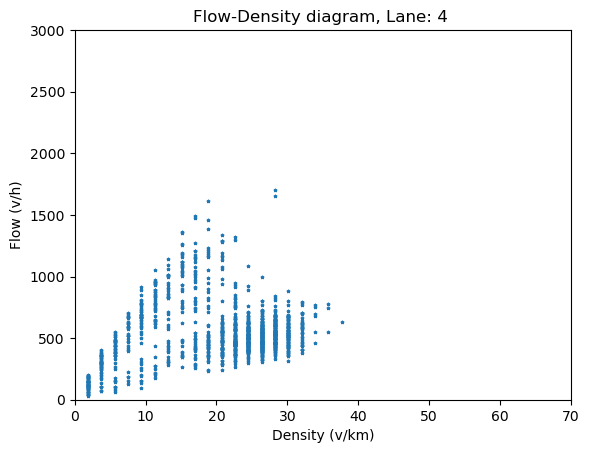

        Time  Lane         Flow    Density      Speed
1440     0.0  -3.0  1186.460282  28.248588  42.000694
1441     5.0  -3.0  1910.984537  45.197740  42.280533
1442    10.0  -3.0  1687.255142  48.964218  34.458942
1443    15.0  -3.0  1469.441610  47.080979  31.210940
1444    20.0  -3.0  1505.310128  48.964218  30.743065
...      ...   ...          ...        ...        ...
2875  7175.0  -3.0  1372.567351  18.832392  72.883326
2876  7180.0  -3.0  1322.593699  20.715631  63.845205
2877  7185.0  -3.0  1130.603124  16.949153  66.705584
2878  7190.0  -3.0  1221.447939  15.065913  81.073607
2879  7195.0  -3.0  1009.068057  11.299435  89.302523

[1440 rows x 5 columns]


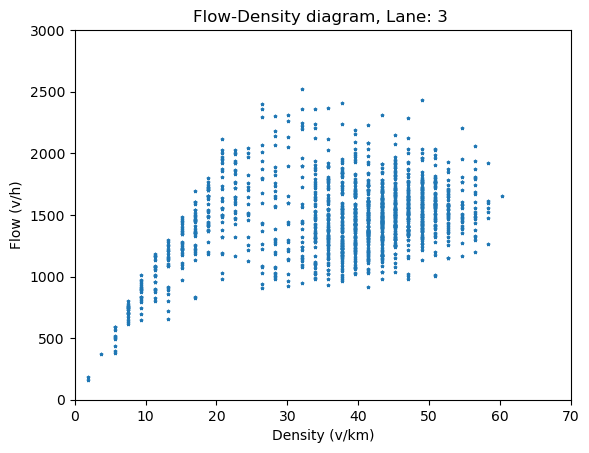

        Time  Lane         Flow    Density      Speed
2880     0.0  -4.0  1222.055749  28.248588  43.260774
2881     5.0  -4.0  1451.933484  33.898305  42.832038
2882    10.0  -4.0  1103.393393  28.248588  39.060126
2883    15.0  -4.0  1259.357927  32.015066  39.336415
2884    20.0  -4.0  1397.193864  35.781544  39.047892
...      ...   ...          ...        ...        ...
4315  7175.0  -4.0  2061.118974  26.365348  78.175298
4316  7180.0  -4.0  1816.309045  24.482109  74.189239
4317  7185.0  -4.0  1521.729094  18.832392  80.803815
4318  7190.0  -4.0  1551.182338  18.832392  82.367782
4319  7195.0  -4.0   954.288171  11.299435  84.454503

[1440 rows x 5 columns]


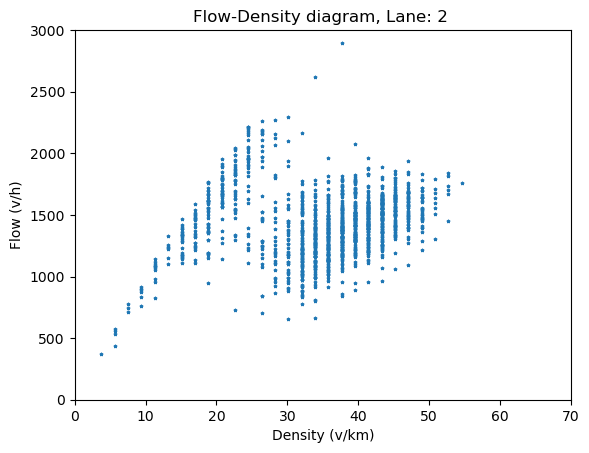

        Time  Lane         Flow    Density      Speed
4320     0.0  -5.0   792.896680  18.832392  42.102814
4321     5.0  -5.0  1519.378012  41.431262  36.672260
4322    10.0  -5.0  1507.526338  41.431262  36.386204
4323    15.0  -5.0  1480.458797  41.431262  35.732892
4324    20.0  -5.0  1303.984654  39.548023  32.972183
...      ...   ...          ...        ...        ...
5755  7175.0  -5.0  1477.570876  20.715631  71.326376
5756  7180.0  -5.0  1836.646184  24.482109  75.019933
5757  7185.0  -5.0  1520.105580  20.715631  73.379642
5758  7190.0  -5.0  1815.142164  24.482109  74.141576
5759  7195.0  -5.0  1553.247811  20.715631  74.979508

[1440 rows x 5 columns]


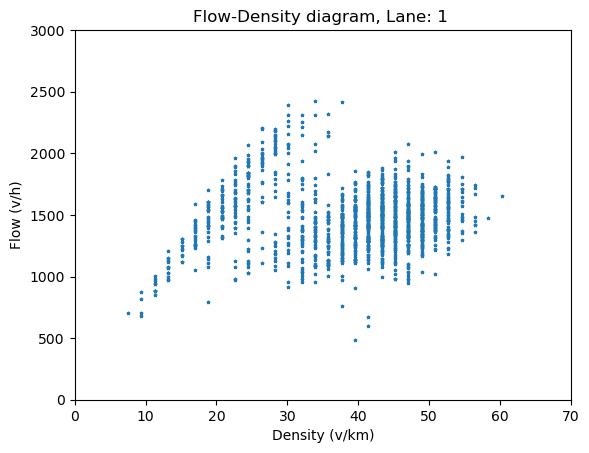

In [15]:
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure


#figure(figsize=(180, 20), dpi=80)
for lane in lanes:
    result2 = result[result['Lane'] == lane]
    
    print (result2)
    flow = result2.Flow
    density = result2.Density
    speed = result2.Speed

    plt.scatter(density, flow, s=4, marker='*')#, c=speed, cmap='RdBu', s=2, vmin=2, vmax=20)
    #plt.scatter(speed, flow)
    plt.xlim([0, 70])
    plt.ylim([0, 3000])
    #plt.colorbar(label='Speed')
    plt.xlabel('Density (v/km)')
    plt.ylabel('Flow (v/h)')
    plt.title(f'Flow-Density diagram, Lane: {lane+6} ')
    plt.savefig('temp.png')#, dpi=fig.dpi)
    plt.show()

In [22]:
result.to_csv("/Users/pedrambeigi/Desktop/Flow-Den-Speed.csv", index=False)

In [26]:
import matplotlib.pyplot as plt
import pandas as pd

data = pd.read_csv(r"/Users/pedrambeigi/Desktop/Flow-Den-Speed.csv")
lanes = [-2, -3, -4, -5]

for i in lanes:
    df = data[data["Lane"] == i]
    plt.scatter(df["Speed"] / 3.6, df["Headway"], s=2)  # switched the axes
    plt.ylim(0, 8)  # setting the range for the y-axis
    plt.xlim(0, 30)  # setting the range for the x-axis
    plt.yticks(range(0, 9, 1))  # setting the integer values for the y-axis
    plt.xticks(range(0, 31, 2))  # setting the integer values for the x-axis
    plt.xlabel('Speed (m/s)')  # labeling the x-axis
    plt.ylabel('Headway (s)')  # labeling the y-axis
    plt.title(f'Speed-Headway diagram, Lane:{i+6}')  # adding a title
    plt.grid(True)  # adding a grid
    plt.show()

KeyError: 'Headway'